# Optimization, visualized

A hands-on tour of the optimization algorithms that train modern ML models.
We start from a one-dimensional bowl and build up — manually computed
gradients, mini-batching, momentum, adaptive scaling, and finally PyTorch's
standard training loop with `SGD`, `Adam`, and `AdamW`.

**How to read it.** Top to bottom. Every section has a derivation, a tiny
implementation, and a picture. Short exercises live at the end of each
section.


## 0. Setup

A single import cell, deterministic seeds, and a handful of tiny plotting
helpers that get reused throughout the notebook so individual sections stay
short.


In [1]:
import math
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(0)
torch.manual_seed(0)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def plot_1d_descent(f: Callable, history, ax=None, w_range=(-3, 7), label=""):
    """Overlay the iterate path on top of `f`'s graph."""
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    ws = np.linspace(*w_range, 200)
    ax.plot(ws, f(ws), "k-", lw=1, label="f(w)")
    hist = np.asarray(history)
    ax.plot(hist, f(hist), "o-", ms=4, lw=1, label=label)
    ax.set_xlabel("w")
    ax.set_ylabel("f(w)")
    return ax


def plot_loss_curve(losses, label="", ax=None, logy=True):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    ax.plot(losses, label=label)
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("step")
    ax.set_ylabel("loss")
    return ax


def plot_contour_with_paths(f, w1_grid, w2_grid, paths, labels, ax=None, levels=20):
    """Contour of `f(w1,w2)` overlaid with several optimizer trajectories."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    W1, W2 = np.meshgrid(w1_grid, w2_grid)
    Z = f(W1, W2)
    ax.contour(W1, W2, Z, levels=levels, cmap="Greys", linewidths=0.6)
    for path, lab in zip(paths, labels):
        p = np.asarray(path)
        ax.plot(p[:, 0], p[:, 1], "o-", ms=3, lw=1, label=lab)
    ax.set_xlabel("w1")
    ax.set_ylabel("w2")
    ax.legend(fontsize=8)
    return ax


def make_linreg_data(n=200, w_true=2.0, b_true=-1.0, noise=0.3, seed=0):
    """Synthetic 1-D linear regression dataset."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-2.0, 2.0, size=n).astype(np.float32)
    y = (w_true * x + b_true + rng.normal(scale=noise, size=n)).astype(np.float32)
    return x, y


def bowl(w1, w2, a=10.0, b=1.0):
    """Ill-conditioned quadratic bowl used in many sections."""
    return 0.5 * (a * w1**2 + b * w2**2)


def bowl_grad(w1, w2, a=10.0, b=1.0):
    return np.array([a * w1, b * w2])


## 1. Scalar gradient descent

Take the simplest possible objective:

$$ f(w) = (w - 3)^2 + 2, \qquad f'(w) = 2(w - 3). $$

Gradient descent repeatedly takes a step *against* the gradient:

$$ w_{t+1} = w_t - \eta \, f'(w_t). $$

The step size $\eta$ (the **learning rate**) controls everything. Too small
and we crawl; too big and we overshoot or diverge.


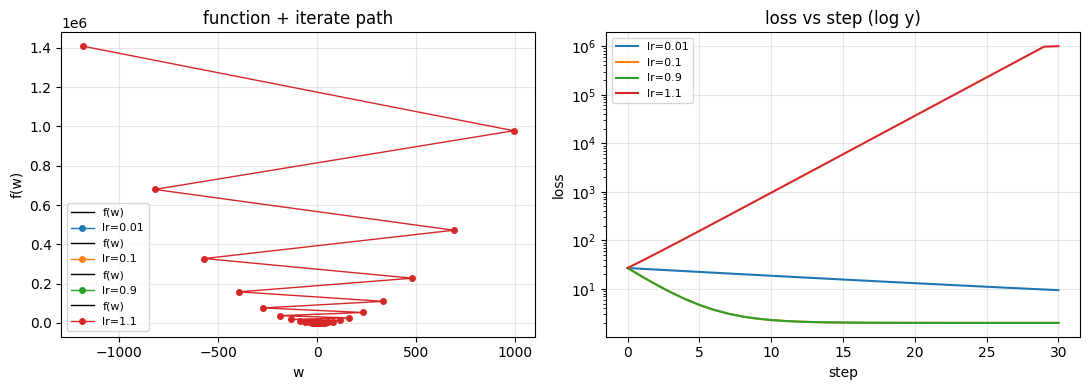

In [2]:
def f1(w):
    return (w - 3) ** 2 + 2


def f1_grad(w):
    return 2 * (w - 3)


def gd_scalar(lr, n_steps=30, w0=-2.0):
    w = w0
    hist = [w]
    for _ in range(n_steps):
        w = w - lr * f1_grad(w)
        hist.append(w)
    return np.array(hist)


learning_rates = [0.01, 0.1, 0.9, 1.1]
histories = {lr: gd_scalar(lr) for lr in learning_rates}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for lr, hist in histories.items():
    plot_1d_descent(f1, hist, ax=axes[0], label=f"lr={lr}")
    # Cap losses so a divergent run does not blow up the y-axis.
    losses = np.clip(f1(hist), None, 1e6)
    plot_loss_curve(losses, label=f"lr={lr}", ax=axes[1])
axes[0].set_title("function + iterate path")
axes[0].legend(fontsize=8)
axes[1].set_title("loss vs step (log y)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


**What to notice.**

- `lr=0.01` converges, but very slowly.
- `lr=0.1` is well-tuned: smooth, fast descent.
- `lr=0.9` oscillates around the optimum but still converges (the step
  factor is `1 - 2*lr = -0.8`, magnitude < 1).
- `lr=1.1` **diverges** — the step factor has magnitude > 1, so each iterate
  is farther from the optimum than the last.

**Exercise.** For this quadratic, the iterate map is
$w_{t+1} - 3 = (1 - 2\eta)(w_t - 3)$. Solve for the largest $\eta$ that
still converges, and check it against the experiment.


## 2. A 2-D loss surface

Real loss surfaces are not symmetric. The cheapest interesting example is
an anisotropic quadratic bowl,

$$ f(w_1, w_2) = \tfrac{1}{2}\,(10\, w_1^2 + w_2^2), \qquad
\nabla f = (10\, w_1,\; w_2). $$

The Hessian has condition number 10, so the surface is a *taco shell*
rather than a round bowl. Gradient descent with a single scalar learning
rate must serve two very different curvatures at once, and that is where
the famous "zig-zag" comes from.


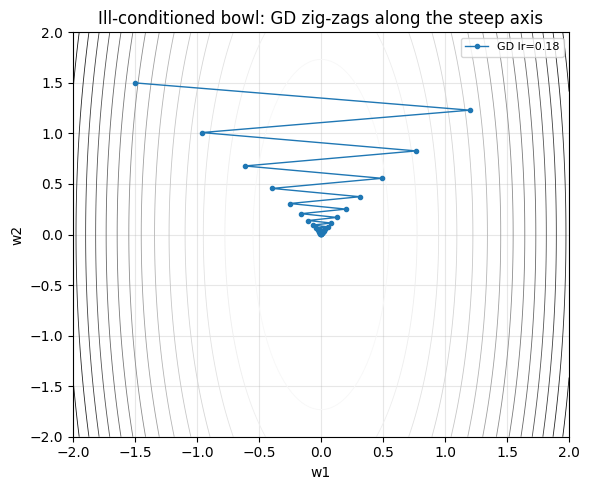

In [3]:
def gd_2d(lr=0.18, n_steps=30, init=(-1.5, 1.5)):
    w = np.array(init, dtype=float)
    hist = [w.copy()]
    for _ in range(n_steps):
        w = w - lr * bowl_grad(*w)
        hist.append(w.copy())
    return np.array(hist)


grid1 = np.linspace(-2, 2, 200)
grid2 = np.linspace(-2, 2, 200)
path = gd_2d()

ax = plot_contour_with_paths(bowl, grid1, grid2, [path], ["GD lr=0.18"])
ax.set_title("Ill-conditioned bowl: GD zig-zags along the steep axis")
plt.tight_layout()
plt.show()


**Exercise.** Increase the learning rate just enough to make the
trajectory diverge along the $w_1$ axis. The threshold is determined by
the larger eigenvalue (here, 10).


## 3. Manual linear regression gradients

For a model $\hat y = w x + b$ and mean-squared-error loss,

$$ L(w, b) = \frac{1}{N}\sum_i (y_i - (w x_i + b))^2, $$

direct differentiation gives

$$ \frac{\partial L}{\partial w} = -\frac{2}{N}\sum_i x_i (y_i - \hat y_i),
\qquad
\frac{\partial L}{\partial b} = -\frac{2}{N}\sum_i (y_i - \hat y_i). $$

We implement these by hand in NumPy and watch the fit improve.


In [4]:
x, y = make_linreg_data(n=200, w_true=2.0, b_true=-1.0, noise=0.3, seed=0)


def mse(w, b, x, y):
    return float(np.mean((y - (w * x + b)) ** 2))


def manual_step(w, b, x, y):
    err = y - (w * x + b)
    dw = -2.0 * np.mean(x * err)
    db = -2.0 * np.mean(err)
    return dw, db


w, b = 0.0, 0.0
lr = 0.05
n_steps = 200
loss_hist, wb_hist = [], []
snapshots = {}
for step in range(n_steps):
    loss_hist.append(mse(w, b, x, y))
    wb_hist.append((w, b))
    if step in (0, 5, 25, n_steps - 1):
        snapshots[step] = (w, b)
    dw, db = manual_step(w, b, x, y)
    w -= lr * dw
    b -= lr * db

wb_hist = np.array(wb_hist)
print(f"final w={w:.4f}, b={b:.4f}, loss={loss_hist[-1]:.5f}")


final w=1.9810, b=-1.0238, loss=0.09379


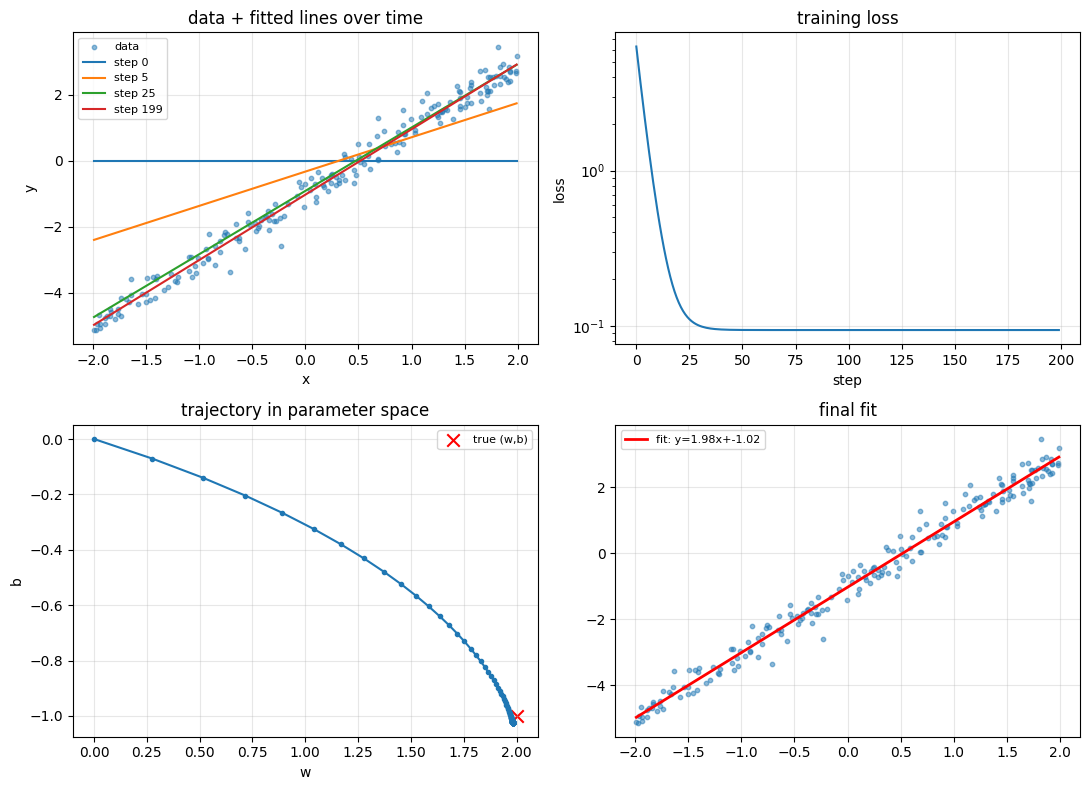

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# (a) data + fitted line at several snapshots
xs = np.linspace(x.min(), x.max(), 50)
axes[0, 0].scatter(x, y, s=10, alpha=0.5, label="data")
for step, (ws, bs) in snapshots.items():
    axes[0, 0].plot(xs, ws * xs + bs, label=f"step {step}")
axes[0, 0].set_title("data + fitted lines over time")
axes[0, 0].legend(fontsize=8)
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")

# (b) loss curve
plot_loss_curve(loss_hist, label="manual GD", ax=axes[0, 1])
axes[0, 1].set_title("training loss")

# (c) (w,b) path
axes[1, 0].plot(wb_hist[:, 0], wb_hist[:, 1], "o-", ms=3)
axes[1, 0].scatter([2.0], [-1.0], c="red", marker="x", s=80, label="true (w,b)")
axes[1, 0].set_xlabel("w")
axes[1, 0].set_ylabel("b")
axes[1, 0].set_title("trajectory in parameter space")
axes[1, 0].legend(fontsize=8)

# (d) final fit
axes[1, 1].scatter(x, y, s=10, alpha=0.5)
axes[1, 1].plot(xs, w * xs + b, "r-", lw=2, label=f"fit: y={w:.2f}x+{b:.2f}")
axes[1, 1].set_title("final fit")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()


**Exercise.** Repeat the run with `lr=0.5`. What happens? Then try
standardising `x` to zero mean / unit variance first — does the same `lr`
behave the same way?


## 4. Manual gradients vs PyTorch autograd

Autograd records every operation on tensors that have `requires_grad=True`
and computes derivatives by walking that graph backwards. Let's verify it
matches our by-hand formulas to machine precision.

Two important PyTorch idioms appear here:

1. **`with torch.no_grad():`** — when we mutate parameters during the
   update, we don't want autograd to track those operations.
2. **`grad.zero_()`** — PyTorch *accumulates* gradients into `.grad`. If we
   don't clear them between steps, the next backward pass adds to the
   stale values.


In [6]:
xt = torch.tensor(x)
yt = torch.tensor(y)

w_t = torch.tensor(0.0, requires_grad=True)
b_t = torch.tensor(0.0, requires_grad=True)

pred = w_t * xt + b_t
loss = ((yt - pred) ** 2).mean()
loss.backward()

dw_manual, db_manual = manual_step(0.0, 0.0, x, y)
print(f"autograd  dw={w_t.grad.item():+.6f}, db={b_t.grad.item():+.6f}")
print(f"manual    dw={dw_manual:+.6f}, db={db_manual:+.6f}")

assert torch.allclose(w_t.grad, torch.tensor(dw_manual), atol=1e-5)
assert torch.allclose(b_t.grad, torch.tensor(db_manual), atol=1e-5)
print("matches to 1e-5")


autograd  dw=-5.531863, db=+1.419576
manual    dw=-5.531863, db=+1.419576
matches to 1e-5


In [7]:
# Mini training loop using autograd. Note the two PyTorch-isms above.
w_t = torch.tensor(0.0, requires_grad=True)
b_t = torch.tensor(0.0, requires_grad=True)
lr = 0.05
for _ in range(200):
    loss = ((yt - (w_t * xt + b_t)) ** 2).mean()
    loss.backward()
    with torch.no_grad():
        w_t -= lr * w_t.grad
        b_t -= lr * b_t.grad
    w_t.grad.zero_()
    b_t.grad.zero_()
print(f"autograd-trained w={w_t.item():.4f}, b={b_t.item():.4f}")


autograd-trained w=1.9810, b=-1.0238


**Exercise.** Comment out the `zero_()` calls and re-run. The
parameters drift wildly because each `backward()` adds to the previous
gradient.


## 5. Full-batch GD vs SGD vs mini-batch SGD

Full-batch GD uses the *exact* gradient of the empirical loss. SGD
estimates that gradient from a single example, and mini-batch SGD uses a
small subset. Smaller batches are cheaper per step but noisier, so they
take a jittery path. Same data, same init, same learning rate — only the
batch size changes.


In [8]:
def train(loader_steps, batch_iter, lr=0.05, init=(0.0, 0.0)):
    """Generic loop. `batch_iter` yields (x_batch, y_batch) per step."""
    w, b = init
    losses, path = [], [(w, b)]
    for xb, yb in batch_iter:
        dw, db = manual_step(w, b, xb, yb)
        w -= lr * dw
        b -= lr * db
        losses.append(mse(w, b, x, y))  # always report full-batch loss
        path.append((w, b))
    return np.array(losses), np.array(path)


def full_batch_iter(n_epochs):
    for _ in range(n_epochs):
        yield x, y


def sgd_iter(n_epochs, batch_size, seed=0):
    rng = np.random.default_rng(seed)
    n = len(x)
    for _ in range(n_epochs):
        idx = rng.permutation(n)
        for start in range(0, n, batch_size):
            sel = idx[start : start + batch_size]
            yield x[sel], y[sel]


n_epochs = 20
loss_fb, path_fb = train(None, full_batch_iter(n_epochs))
loss_sgd, path_sgd = train(None, sgd_iter(n_epochs, batch_size=1))
loss_mb, path_mb = train(None, sgd_iter(n_epochs, batch_size=32))

print(f"updates: full={len(loss_fb)}, sgd={len(loss_sgd)}, mini-batch={len(loss_mb)}")


updates: full=20, sgd=4000, mini-batch=140


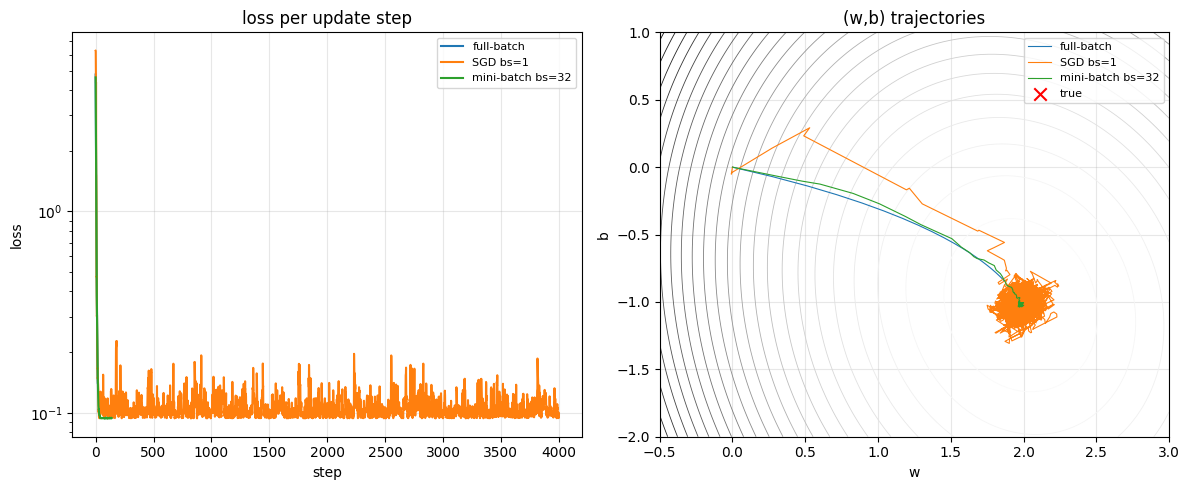

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_loss_curve(loss_fb, label="full-batch", ax=axes[0])
plot_loss_curve(loss_sgd, label="SGD bs=1", ax=axes[0])
plot_loss_curve(loss_mb, label="mini-batch bs=32", ax=axes[0])
axes[0].set_title("loss per update step")
axes[0].legend(fontsize=8)

# Contour of true MSE over (w, b).
ws_grid = np.linspace(-0.5, 3.0, 80)
bs_grid = np.linspace(-2.0, 1.0, 80)
W, B = np.meshgrid(ws_grid, bs_grid)
err = y[None, None, :] - (W[..., None] * x[None, None, :] + B[..., None])
Z = (err**2).mean(axis=-1)
axes[1].contour(W, B, Z, levels=25, cmap="Greys", linewidths=0.6)
for p, lab in [(path_fb, "full-batch"), (path_sgd, "SGD bs=1"), (path_mb, "mini-batch bs=32")]:
    axes[1].plot(p[:, 0], p[:, 1], "-", lw=0.8, label=lab)
axes[1].scatter([2.0], [-1.0], c="red", marker="x", s=80, label="true")
axes[1].set_xlabel("w")
axes[1].set_ylabel("b")
axes[1].set_title("(w,b) trajectories")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


**Why it matters.** SGD's gradient estimate is unbiased but noisy.
That noise is not always bad — it can help escape sharp minima and
regularises learning in deep nets — but it does mean you usually need
either a small learning rate or a schedule that decays it over time.

**Exercise.** Run SGD with `bs=1` for 50 epochs. Does the final loss keep
improving, or does it plateau around a fluctuating value?


## 6. SGD on a 2-D linear regression surface

Now both parameters matter to the loss. We build a problem
$y = w_1 x_1 + w_2 x_2 + \varepsilon$, compute the *full* MSE surface
on a grid, and watch the three optimizers move across it.

We also draw, at one snapshot, the **true** full-batch gradient vs the
**sampled** mini-batch gradient at the same point. The mini-batch arrow
is noisy, but on average it points in the same direction as the
full-batch arrow.


In [10]:
rng = np.random.default_rng(0)
N2 = 256
X2 = rng.normal(size=(N2, 2)).astype(np.float32)
W_TRUE = np.array([1.5, -0.8], dtype=np.float32)
y2 = X2 @ W_TRUE + 0.2 * rng.normal(size=N2).astype(np.float32)


def loss_full(w):
    return float(np.mean((X2 @ w - y2) ** 2))


def grad_full(w):
    err = X2 @ w - y2
    return (2.0 / N2) * (X2.T @ err)


def grad_mini(w, batch_size, rng):
    idx = rng.choice(N2, size=batch_size, replace=False)
    err = X2[idx] @ w - y2[idx]
    return (2.0 / batch_size) * (X2[idx].T @ err)


def run_sgd(lr=0.1, batch_size=32, n_steps=60, init=(-2.0, 2.0), seed=1):
    rng = np.random.default_rng(seed)
    w = np.array(init, dtype=np.float32)
    path = [w.copy()]
    for _ in range(n_steps):
        g = grad_full(w) if batch_size >= N2 else grad_mini(w, batch_size, rng)
        w = w - lr * g
        path.append(w.copy())
    return np.array(path)


path_full = run_sgd(batch_size=N2)
path_mini = run_sgd(batch_size=32)
path_sgd1 = run_sgd(batch_size=1, lr=0.05)


def loss_grid(w1g, w2g):
    Z = np.empty((len(w2g), len(w1g)))
    for i, w2 in enumerate(w2g):
        for j, w1 in enumerate(w1g):
            Z[i, j] = loss_full(np.array([w1, w2]))
    return Z


w1g = np.linspace(-2.5, 2.5, 60)
w2g = np.linspace(-2.5, 2.5, 60)
Z = loss_grid(w1g, w2g)


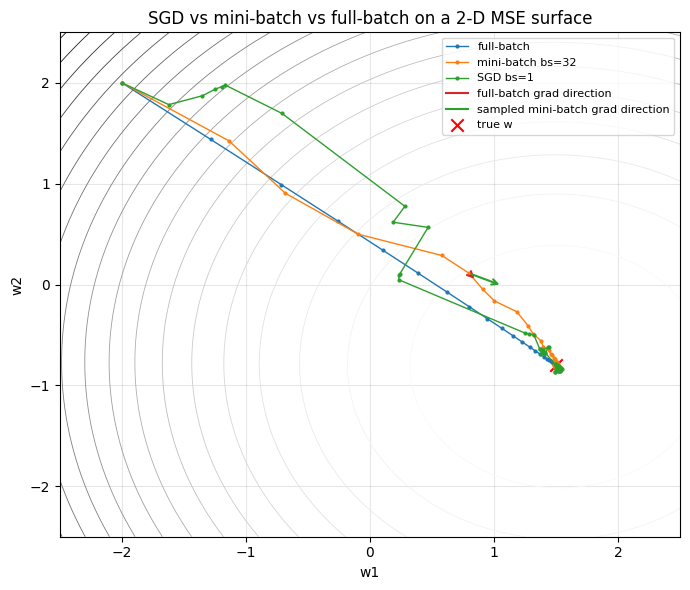

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
W1, W2 = np.meshgrid(w1g, w2g)
ax.contour(W1, W2, Z, levels=20, cmap="Greys", linewidths=0.6)
for p, lab in [(path_full, "full-batch"), (path_mini, "mini-batch bs=32"), (path_sgd1, "SGD bs=1")]:
    ax.plot(p[:, 0], p[:, 1], "o-", ms=2, lw=1, label=lab)

# At step 5, compare full-batch vs sampled gradient direction.
rng = np.random.default_rng(0)
pt = path_mini[5]
g_true = grad_full(pt)
g_samp = grad_mini(pt, batch_size=4, rng=rng)
scale = 0.04
ax.annotate("", xy=pt - scale * g_true, xytext=pt, arrowprops=dict(arrowstyle="->", color="C3", lw=1.5))
ax.annotate("", xy=pt - scale * g_samp, xytext=pt, arrowprops=dict(arrowstyle="->", color="C2", lw=1.5))
ax.plot([], [], "C3-", label="full-batch grad direction")
ax.plot([], [], "C2-", label="sampled mini-batch grad direction")
ax.scatter([W_TRUE[0]], [W_TRUE[1]], c="red", marker="x", s=80, label="true w")
ax.legend(fontsize=8)
ax.set_xlabel("w1")
ax.set_ylabel("w2")
ax.set_title("SGD vs mini-batch vs full-batch on a 2-D MSE surface")
plt.tight_layout()
plt.show()


### Optional: interactive widget

If `ipywidgets` is installed, drag the sliders to see how the trajectory
responds to learning rate, batch size, and noise level. Otherwise the
notebook prints a message and skips this cell.


In [ ]:
import signal


def _interactive_plot(lr, batch_size, noise_scale):
    rng = np.random.default_rng(0)
    X2_local = rng.normal(size=(N2, 2)).astype(np.float32)
    y_local = X2_local @ W_TRUE + noise_scale * rng.normal(size=N2).astype(np.float32)

    def grad(w, idx=None):
        Xb = X2_local if idx is None else X2_local[idx]
        yb = y_local if idx is None else y_local[idx]
        return (2.0 / len(Xb)) * (Xb.T @ (Xb @ w - yb))

    w = np.array([-2.0, 2.0], dtype=np.float32)
    path = [w.copy()]
    rng2 = np.random.default_rng(1)
    for _ in range(80):
        if batch_size >= N2:
            g = grad(w)
        else:
            idx = rng2.choice(N2, size=batch_size, replace=False)
            g = grad(w, idx)
        w = w - lr * g
        path.append(w.copy())
    path = np.array(path)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.contour(W1, W2, Z, levels=20, cmap="Greys", linewidths=0.6)
    ax.plot(path[:, 0], path[:, 1], "o-", ms=3, lw=1, color="C0")
    ax.scatter([W_TRUE[0]], [W_TRUE[1]], c="red", marker="x", s=80)
    ax.set_xlabel("w1")
    ax.set_ylabel("w2")
    ax.set_title(f"lr={lr:.3f}, batch={batch_size}, noise={noise_scale:.2f}")
    plt.show()


class _WidgetTimeout(Exception):
    pass


def _raise_widget_timeout(signum, frame):
    raise _WidgetTimeout


try:
    from ipywidgets import FloatSlider, IntSlider, interact

    # SIGALRM is only available on Unix; guard the call so the notebook never
    # hangs for more than a minute while building the widget.
    _has_alarm = hasattr(signal, "SIGALRM")
    if _has_alarm:
        signal.signal(signal.SIGALRM, _raise_widget_timeout)
        signal.alarm(30)
    try:
        interact(
            _interactive_plot,
            lr=FloatSlider(value=0.1, min=0.005, max=0.4, step=0.005),
            batch_size=IntSlider(value=32, min=1, max=N2, step=1),
            noise_scale=FloatSlider(value=0.2, min=0.0, max=1.0, step=0.05),
        )
    finally:
        if _has_alarm:
            signal.alarm(0)
except _WidgetTimeout:
    print("Interactive widget timed out after 30 seconds; skipping.")
except Exception as exc:
    print(f"ipywidgets not available ({exc.__class__.__name__}); skipping widget.")


**Exercise.** Push the noise scale up to 1.0. Which optimizer
suffers more, full-batch or SGD bs=1?


## 7. Momentum

Momentum keeps a running average of past gradients so the iterate behaves
like a heavy ball rolling downhill: oscillations get damped and consistent
directions get amplified.

$$ v_t = \beta\, v_{t-1} + g_t, \qquad \theta_{t+1} = \theta_t - \eta\, v_t. $$

The hyperparameter $\beta \in [0, 1)$ controls how much history to carry.
$\beta = 0$ recovers vanilla GD.


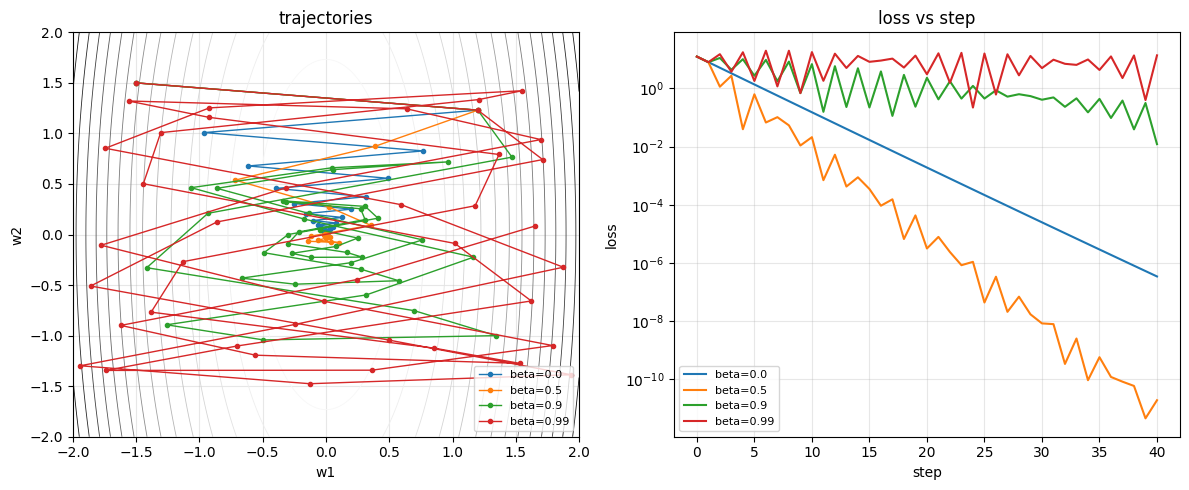

In [13]:
def gd_momentum(beta, lr=0.18, n_steps=40, init=(-1.5, 1.5)):
    w = np.array(init, dtype=float)
    v = np.zeros_like(w)
    path, losses = [w.copy()], [bowl(*w)]
    for _ in range(n_steps):
        g = bowl_grad(*w)
        v = beta * v + g
        w = w - lr * v
        path.append(w.copy())
        losses.append(bowl(*w))
    return np.array(path), np.array(losses)


betas = [0.0, 0.5, 0.9, 0.99]
results = {b: gd_momentum(b) for b in betas}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_contour_with_paths(
    bowl,
    np.linspace(-2, 2, 200),
    np.linspace(-2, 2, 200),
    [r[0] for r in results.values()],
    [f"beta={b}" for b in betas],
    ax=axes[0],
)
axes[0].set_title("trajectories")
for b, (_, losses) in results.items():
    plot_loss_curve(losses, label=f"beta={b}", ax=axes[1])
axes[1].set_title("loss vs step")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


**What to notice.** With `beta=0.9` the iterate hugs the bottom of
the valley instead of bouncing across it; `beta=0.99` overshoots because
it carries too much momentum.

**Exercise.** Add a Nesterov-style lookahead and compare. (Spec:
$g_t = \nabla f(\theta_t - \eta\beta v_{t-1})$.)


## 8. RMSProp-style adaptive scaling

The zig-zag in Section 2 happens because one scalar learning rate has to
serve two very different curvatures. **Per-coordinate** adaptive scaling
fixes this: keep a running average of *squared* gradients and divide by
its square root.

$$ s_t = \beta s_{t-1} + (1 - \beta) g_t^2, \qquad
\theta_{t+1} = \theta_t - \eta \frac{g_t}{\sqrt{s_t} + \epsilon}. $$

Coordinates with consistently large gradients get *smaller* effective
learning rates; sluggish coordinates speed up.


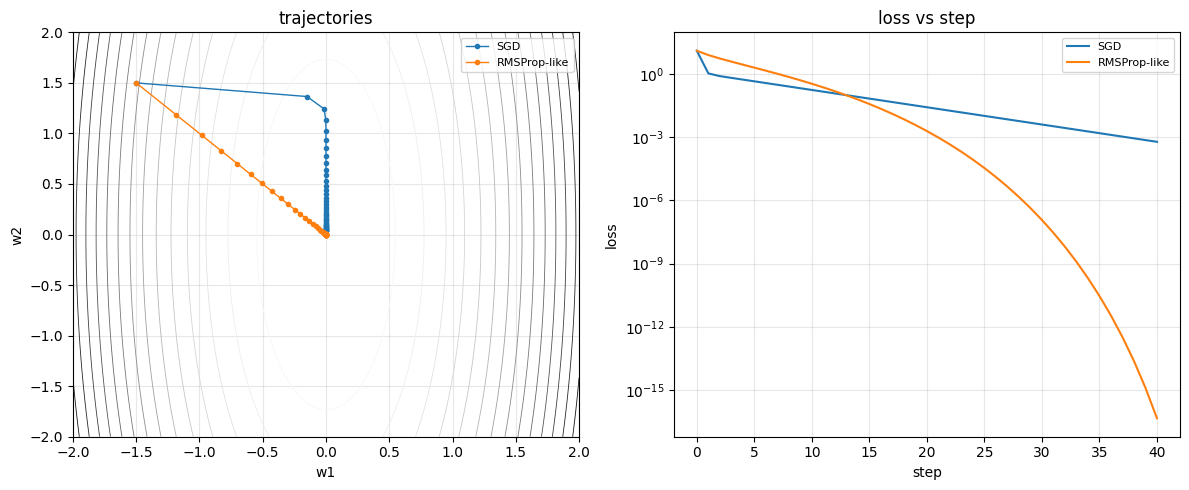

In [14]:
def rmsprop(lr=0.1, beta=0.9, eps=1e-8, n_steps=40, init=(-1.5, 1.5)):
    w = np.array(init, dtype=float)
    s = np.zeros_like(w)
    path, losses = [w.copy()], [bowl(*w)]
    for _ in range(n_steps):
        g = bowl_grad(*w)
        s = beta * s + (1 - beta) * g**2
        w = w - lr * g / (np.sqrt(s) + eps)
        path.append(w.copy())
        losses.append(bowl(*w))
    return np.array(path), np.array(losses)


def plain_sgd_bowl(lr=0.09, n_steps=40, init=(-1.5, 1.5)):
    w = np.array(init, dtype=float)
    path, losses = [w.copy()], [bowl(*w)]
    for _ in range(n_steps):
        w = w - lr * bowl_grad(*w)
        path.append(w.copy())
        losses.append(bowl(*w))
    return np.array(path), np.array(losses)


sgd_p, sgd_l = plain_sgd_bowl()
rms_p, rms_l = rmsprop()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_contour_with_paths(
    bowl,
    np.linspace(-2, 2, 200),
    np.linspace(-2, 2, 200),
    [sgd_p, rms_p],
    ["SGD", "RMSProp-like"],
    ax=axes[0],
)
axes[0].set_title("trajectories")
plot_loss_curve(sgd_l, "SGD", ax=axes[1])
plot_loss_curve(rms_l, "RMSProp-like", ax=axes[1])
axes[1].set_title("loss vs step")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


**Exercise.** What happens if `eps` is set to a very large value
(say, 1.0)? Re-run and explain why RMSProp degrades toward plain SGD.


## 9. Adam from scratch

Adam = momentum + RMSProp + a bias correction that compensates for
initializing the moving averages at zero.

$$
\begin{aligned}
 m_t &= \beta_1 m_{t-1} + (1 - \beta_1) g_t, &
 v_t &= \beta_2 v_{t-1} + (1 - \beta_2) g_t^2, \\
 \hat m_t &= m_t / (1 - \beta_1^t), &
 \hat v_t &= v_t / (1 - \beta_2^t), \\
 \theta_{t+1} &= \theta_t - \eta\, \hat m_t / (\sqrt{\hat v_t} + \epsilon). & &
\end{aligned}
$$


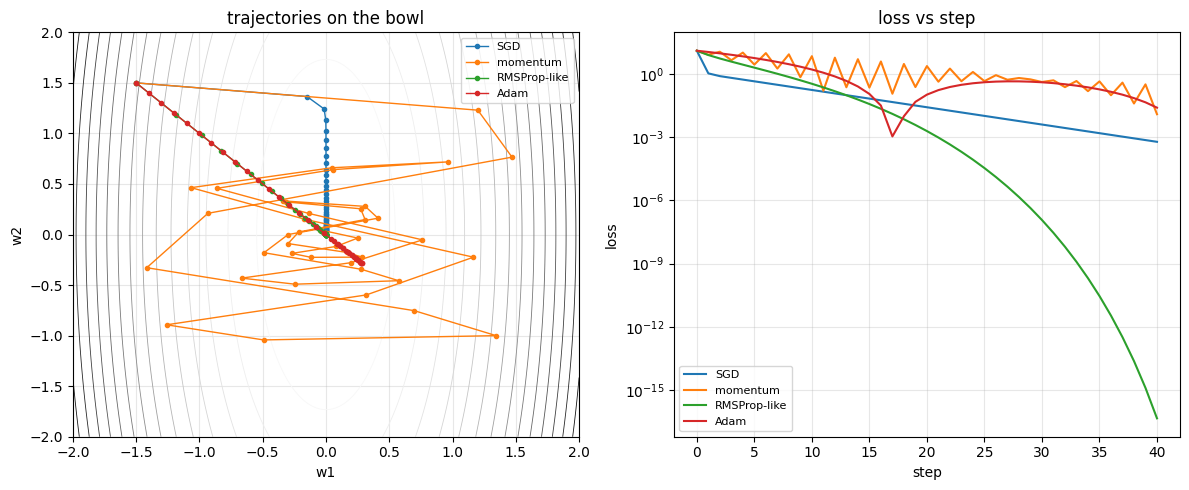

In [15]:
def adam(lr=0.1, beta1=0.9, beta2=0.999, eps=1e-8, n_steps=40, init=(-1.5, 1.5)):
    w = np.array(init, dtype=float)
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    path, losses = [w.copy()], [bowl(*w)]
    for t in range(1, n_steps + 1):
        g = bowl_grad(*w)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        w = w - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(w.copy())
        losses.append(bowl(*w))
    return np.array(path), np.array(losses)


mom_p, mom_l = gd_momentum(beta=0.9)
rms_p2, rms_l2 = rmsprop()
adam_p, adam_l = adam()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_contour_with_paths(
    bowl,
    np.linspace(-2, 2, 200),
    np.linspace(-2, 2, 200),
    [sgd_p, mom_p, rms_p2, adam_p],
    ["SGD", "momentum", "RMSProp-like", "Adam"],
    ax=axes[0],
)
axes[0].set_title("trajectories on the bowl")
for losses, lab in [(sgd_l, "SGD"), (mom_l, "momentum"), (rms_l2, "RMSProp-like"), (adam_l, "Adam")]:
    plot_loss_curve(losses, label=lab, ax=axes[1])
axes[1].set_title("loss vs step")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


**Exercise.** Drop the bias correction (use `m_t` / `v_t` directly).
What happens in the first ~10 steps? Why does this matter most when
$\beta_2$ is close to 1?


## 10. AdamW: decoupled weight decay

Adding an L2 penalty $\tfrac{\lambda}{2}\lVert\theta\rVert^2$ to the loss
inserts $\lambda \theta$ into the gradient. Under plain SGD this is the
same as **weight decay** — every step shrinks $\theta$ toward zero by a
factor $1 - \eta\lambda$.

Under Adam, the $\lambda\theta$ term goes through the adaptive denominator
$\sqrt{\hat v}$ first. Parameters with large historical gradients get
*less* shrinkage than parameters with small gradients — almost the
opposite of what you want.

**AdamW** decouples the shrinkage from the adaptive update:

$$ \theta_{t+1} = \theta_t - \eta\, \hat m_t / (\sqrt{\hat v_t} + \epsilon) -\eta \lambda \theta_t. $$

The next cell trains a 50-dimensional least-squares problem with both
flavours and watches $\lVert\theta\rVert$.


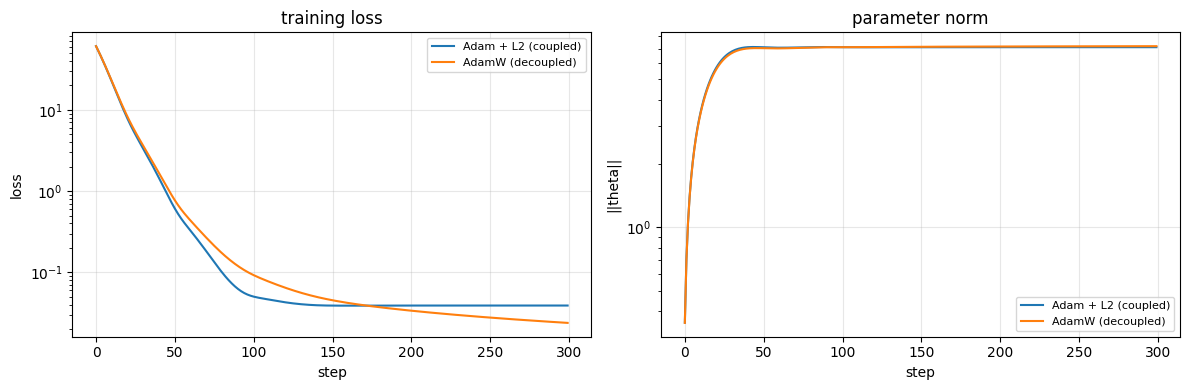

In [16]:
rng = np.random.default_rng(0)
d = 50
N3 = 200
X3 = rng.normal(size=(N3, d)).astype(np.float32)
w_star = rng.normal(size=d).astype(np.float32)
y3 = X3 @ w_star + 0.1 * rng.normal(size=N3).astype(np.float32)


def _grad_ls(w):
    return (2.0 / N3) * (X3.T @ (X3 @ w - y3))


def _loss_ls(w):
    return float(np.mean((X3 @ w - y3) ** 2))


def adam_train(coupled, lam=0.05, lr=0.05, n_steps=300):
    w = np.zeros(d, dtype=np.float32)
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    losses, norms = [], []
    beta1, beta2, eps = 0.9, 0.999, 1e-8
    for t in range(1, n_steps + 1):
        g = _grad_ls(w)
        if coupled:
            g = g + lam * w  # L2 penalty folded into the gradient
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        update = lr * (m / (1 - beta1**t)) / (np.sqrt(v / (1 - beta2**t)) + eps)
        w = w - update
        if not coupled:
            w = w - lr * lam * w  # decoupled weight decay
        losses.append(_loss_ls(w))
        norms.append(float(np.linalg.norm(w)))
    return np.array(losses), np.array(norms)


l_coupled, n_coupled = adam_train(coupled=True)
l_decoupled, n_decoupled = adam_train(coupled=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_loss_curve(l_coupled, "Adam + L2 (coupled)", ax=axes[0])
plot_loss_curve(l_decoupled, "AdamW (decoupled)", ax=axes[0])
axes[0].set_title("training loss")
axes[0].legend(fontsize=8)
axes[1].plot(n_coupled, label="Adam + L2 (coupled)")
axes[1].plot(n_decoupled, label="AdamW (decoupled)")
axes[1].set_yscale("log")
axes[1].set_xlabel("step")
axes[1].set_ylabel("||theta||")
axes[1].set_title("parameter norm")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


**Takeaway.** AdamW shrinks every parameter by the same multiplicative
factor each step, regardless of historical gradient magnitude. This is the
default optimizer for transformers for exactly this reason.

**Exercise.** Vary `lam` between 0.0 and 0.5. At what value does coupled
Adam start to look qualitatively similar to AdamW, and why?


## 11. PyTorch optimizers and the standard training loop

The mechanics from Sections 1–10 are packaged inside `torch.optim`. We
build a tiny MLP for $y = \sin(x) + \varepsilon$ and train four copies of
it with different optimizers using the **canonical training step**:

```
optimizer.zero_grad()
pred = model(xb)
loss = F.mse_loss(pred, yb)
loss.backward()
optimizer.step()
```


In [17]:
rng = np.random.default_rng(0)
N4 = 400
x_sin = rng.uniform(-2 * math.pi, 2 * math.pi, size=N4).astype(np.float32)
y_sin = np.sin(x_sin).astype(np.float32) + 0.1 * rng.normal(size=N4).astype(np.float32)

ds = TensorDataset(torch.from_numpy(x_sin).unsqueeze(1), torch.from_numpy(y_sin).unsqueeze(1))
loader = DataLoader(ds, batch_size=32, shuffle=True)


def make_model(seed=0):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 1))


def train_model(opt_factory, n_epochs=80):
    model = make_model()
    optimizer = opt_factory(model.parameters())
    losses = []
    for _ in range(n_epochs):
        epoch_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = F.mse_loss(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        losses.append(epoch_loss / len(ds))
    return model, np.array(losses)


configs = {
    "SGD": lambda p: torch.optim.SGD(p, lr=0.02),
    "SGD+mom": lambda p: torch.optim.SGD(p, lr=0.02, momentum=0.9),
    "Adam": lambda p: torch.optim.Adam(p, lr=0.01),
    "AdamW": lambda p: torch.optim.AdamW(p, lr=0.01, weight_decay=0.01),
}
results = {name: train_model(fac) for name, fac in configs.items()}


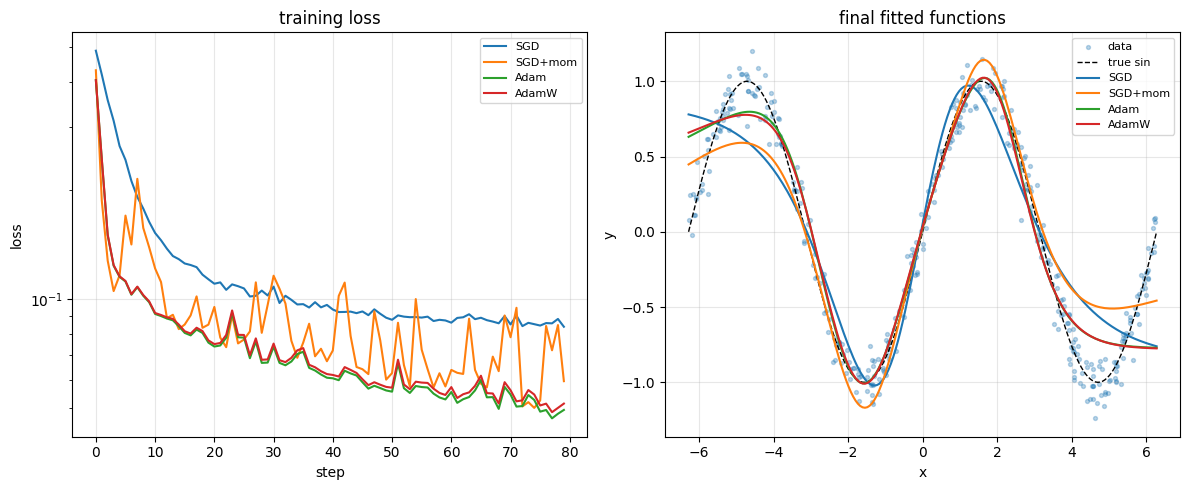

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, (_, losses) in results.items():
    plot_loss_curve(losses, label=name, ax=axes[0])
axes[0].set_title("training loss")
axes[0].legend(fontsize=8)

x_dense = torch.linspace(-2 * math.pi, 2 * math.pi, 200).unsqueeze(1)
axes[1].scatter(x_sin, y_sin, s=8, alpha=0.3, label="data")
axes[1].plot(x_dense.numpy(), np.sin(x_dense.numpy()), "k--", lw=1, label="true sin")
with torch.no_grad():
    for name, (model, _) in results.items():
        axes[1].plot(x_dense.numpy(), model(x_dense).numpy(), label=name)
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("final fitted functions")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


**Exercise.** Increase the network width or depth and re-time the
training. Do adaptive optimizers stay ahead, or does plain SGD catch up
once the loss surface is "nicer"?


## 12. Parameter groups

Common practice for transformers: apply weight decay to weight matrices
but **not** to biases or LayerNorm parameters. PyTorch optimizers accept a
list of *parameter groups*, each with its own hyperparameters.


In [19]:
model = make_model()

decay_params, nodecay_params = [], []
for name, p in model.named_parameters():
    (nodecay_params if name.endswith("bias") else decay_params).append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": decay_params, "weight_decay": 0.05},
        {"params": nodecay_params, "weight_decay": 0.0},
    ],
    lr=0.01,
)

for _ in range(40):
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = F.mse_loss(model(xb), yb)
        loss.backward()
        optimizer.step()

w_norms = [p.detach().norm().item() for p in decay_params]
b_norms = [p.detach().norm().item() for p in nodecay_params]
print(f"final weight-matrix norms (with decay):     {[f'{x:.3f}' for x in w_norms]}")
print(f"final bias norms (no decay):                {[f'{x:.3f}' for x in b_norms]}")


final weight-matrix norms (with decay):     ['4.229', '1.302']
final bias norms (no decay):                ['5.657', '0.042']


**Why exclude biases?** They are low-dimensional, often centred near
zero already, and shrinking them rarely helps generalisation but can hurt
expressivity. The same logic applies to normalisation parameters.


## 13. Going further — exercises

A handful of small extensions to deepen the intuition.

1. **Section 1.** Derive analytically the range of learning rates for
   which GD converges on the 1-D quadratic. Confirm experimentally.
2. **Section 2.** Run GD on the bowl with `lr=0.21`. What happens, and
   how does it relate to the largest eigenvalue of the Hessian?
3. **Section 5.** Add a learning-rate schedule that halves `lr` every 5
   epochs to SGD `bs=1`. Does it close the gap to mini-batch SGD?
4. **Section 7.** Implement Nesterov momentum and compare to plain
   momentum on the same bowl.
5. **Section 9.** Compare your hand-rolled Adam to `torch.optim.Adam` on
   the bowl — they should match to within floating-point error.
6. **Section 10.** Replicate the experiment using `torch.optim.Adam(...)`
   with `weight_decay` (coupled) vs `torch.optim.AdamW(...)`.

Two starter TODO cells:


In [20]:
# TODO: Implement Nesterov momentum on the 2-D bowl and overlay its
# trajectory on top of the Section 7 plot.


def nesterov(beta, lr=0.18, n_steps=40, init=(-1.5, 1.5)):
    raise NotImplementedError


In [21]:
# TODO: Re-run Section 11 with a cosine learning-rate schedule
# (torch.optim.lr_scheduler.CosineAnnealingLR) and compare the final fits.
